# Classification

## Setup

In [1]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as st
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

## Load Data

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)
X, y = mnist["data"], mnist["target"]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, random_state=42
)

## CNN


In [4]:
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

In [5]:
# Load Data
(xtr, ytr), (xte, yte) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# normalize between [0, 1]
xtr = (xtr/255.0).astype("float32")[...,None]
xte = (xte/255.0).astype("float32")[...,None]

In [7]:
# create train and testy tf.data
BATCH = 128
ds_train = tf.data.Dataset.from_tensor_slices((xtr, ytr)).shuffle(60000).batch(BATCH).prefetch(tf.data.AUTOTUNE)
ds_test = tf.data.Dataset.from_tensor_slices((xte, yte)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

In [8]:
# Model (small but strong)
def make_model():
    input = layers.Input((28,28,1))
    # x = aug(input)
    x = layers.Conv2D(32,3,padding="same",activation="relu")(input)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32,3,padding="same",activation="relu")(x)
    x = layers.MaxPool2D()(x); x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64,3,padding="same",activation="relu")(x);
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64,3,padding="same",activation="relu")(x)
    x = layers.MaxPool2D()(x);
    x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128,activation="relu")(x); x = layers.Dropout(0.5)(x)
    output = layers.Dense(10,activation="softmax")(x)
    m = models.Model(input,output)
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

model = make_model()

### Train and inspect one batch

In [9]:
xb, yb = next(iter(ds_train))
loss, acc = model.train_on_batch(xb, yb)
print(f"After 1 batch -> loss:{loss:.4f}, acc:{acc:.4f}")

After 1 batch -> loss:4.2870, acc:0.0859


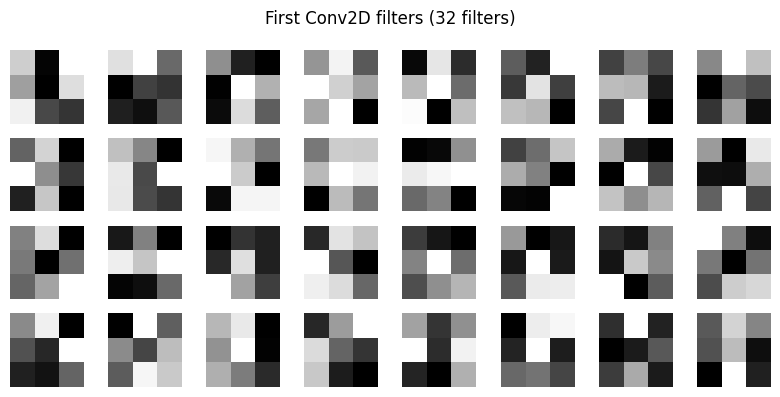

In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# find first Conv2D layer
conv_layer = None
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        conv_layer = layer
        break

if conv_layer is None:
    raise ValueError("No Conv2D layer found in model!")

# get weights
w = conv_layer.get_weights()[0]  # shape: (kernel_h, kernel_w, in_channels, out_channels)

# normalize for display
wmin, wmax = w.min(), w.max()
w_vis = (w - wmin) / (wmax - wmin + 1e-8)

# plot up to 32 filters
n_filters = min(w_vis.shape[-1], 32)

plt.figure(figsize=(8,4))
for i in range(n_filters):
    plt.subplot(4,8,i+1)
    # show channel 0 (MNIST is grayscale so in_channels = 1)
    plt.imshow(w_vis[:,:,0,i], cmap="gray")
    plt.axis("off")

plt.suptitle(f"First Conv2D filters ({n_filters} filters)")
plt.tight_layout()
plt.show()


In [11]:
for i, l in enumerate(model.layers):
    print(i, l.name, type(l), l.weights and len(l.get_weights()))

0 input_layer <class 'keras.src.layers.core.input_layer.InputLayer'> []
1 conv2d <class 'keras.src.layers.convolutional.conv2d.Conv2D'> 2
2 batch_normalization <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'> 4
3 conv2d_1 <class 'keras.src.layers.convolutional.conv2d.Conv2D'> 2
4 max_pooling2d <class 'keras.src.layers.pooling.max_pooling2d.MaxPooling2D'> []
5 dropout <class 'keras.src.layers.regularization.dropout.Dropout'> []
6 conv2d_2 <class 'keras.src.layers.convolutional.conv2d.Conv2D'> 2
7 batch_normalization_1 <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'> 4
8 conv2d_3 <class 'keras.src.layers.convolutional.conv2d.Conv2D'> 2
9 max_pooling2d_1 <class 'keras.src.layers.pooling.max_pooling2d.MaxPooling2D'> []
10 dropout_1 <class 'keras.src.layers.regularization.dropout.Dropout'> []
11 flatten <class 'keras.src.layers.reshaping.flatten.Flatten'> []
12 dense <class 'keras.src.layers.core.dense.Dense'> 2
13 dropout_2 <cla

### Train the rest

In [12]:
# Train (with val split, early stop, LR schedule)
cb = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, monitor="val_loss")
]
# history = model.fit(ds_train, epochs=10, validation_data=ds_test, verbose=2)
hist = model.fit(ds_train, epochs=15, validation_data=ds_test, callbacks=cb, verbose=2)

Epoch 1/15
469/469 - 19s - 40ms/step - accuracy: 0.7603 - loss: 0.6881 - val_accuracy: 0.9751 - val_loss: 0.1341 - learning_rate: 1.0000e-03
Epoch 2/15
469/469 - 4s - 9ms/step - accuracy: 0.9053 - loss: 0.2759 - val_accuracy: 0.9880 - val_loss: 0.0407 - learning_rate: 1.0000e-03
Epoch 3/15
469/469 - 4s - 9ms/step - accuracy: 0.9421 - loss: 0.1795 - val_accuracy: 0.9897 - val_loss: 0.0335 - learning_rate: 1.0000e-03
Epoch 4/15
469/469 - 4s - 9ms/step - accuracy: 0.9609 - loss: 0.1227 - val_accuracy: 0.9923 - val_loss: 0.0263 - learning_rate: 1.0000e-03
Epoch 5/15
469/469 - 4s - 9ms/step - accuracy: 0.9717 - loss: 0.0936 - val_accuracy: 0.9916 - val_loss: 0.0254 - learning_rate: 1.0000e-03
Epoch 6/15
469/469 - 4s - 9ms/step - accuracy: 0.9780 - loss: 0.0746 - val_accuracy: 0.9917 - val_loss: 0.0306 - learning_rate: 1.0000e-03
Epoch 7/15
469/469 - 4s - 9ms/step - accuracy: 0.9811 - loss: 0.0656 - val_accuracy: 0.9932 - val_loss: 0.0210 - learning_rate: 1.0000e-03
Epoch 8/15
469/469 - 4s -

In [17]:
model.save("mnist_cnn.keras")

In [18]:
from tensorflow.keras.models import load_model
loaded_model = load_model("mnist_cnn.keras")

In [19]:
# Test accuracy
test_acc = model.evaluate(ds_test, verbose=0)[1]
print("Test accuracy:", round(float(test_acc), 4))

Test accuracy: 0.995


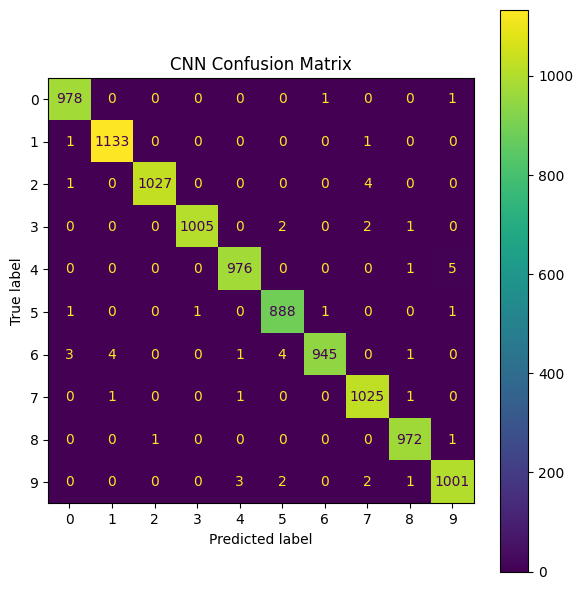

In [20]:
# Confusion matrix
yp = model.predict(ds_test, verbose=0)
y_pred = yp.argmax(axis=1)
fig, ax = plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay.from_predictions(yte, y_pred, ax=ax, values_format='d')
ax.set_title("CNN Confusion Matrix"); plt.tight_layout(); plt.show()


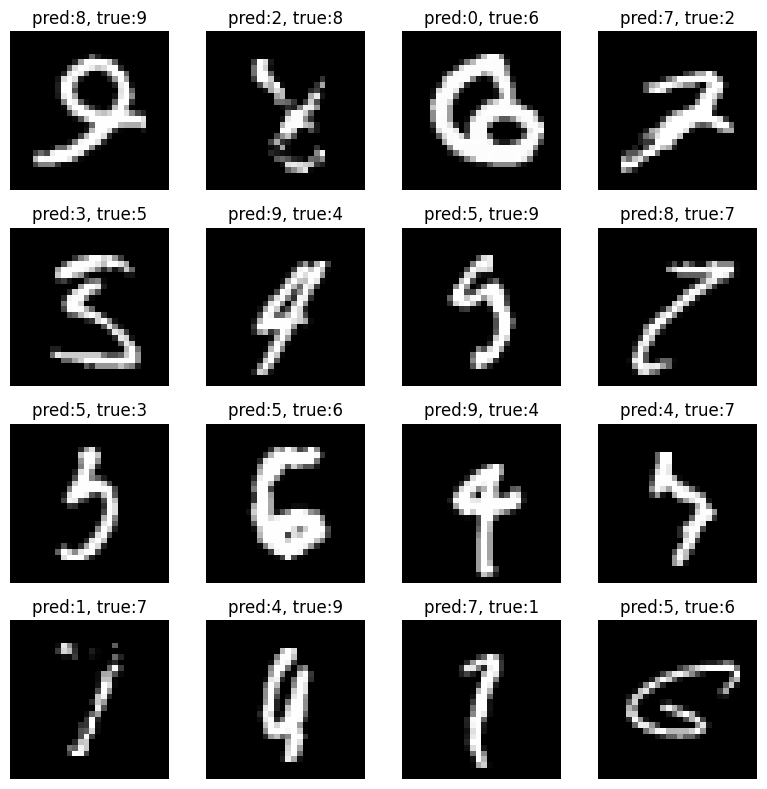

In [23]:
# 7) Show 16 mistakes
mis = np.where(y_pred != yte)[0]
if len(mis) > 0:
    pick = np.random.RandomState(42).choice(mis, size=min(16, len(mis)), replace=False)
    plt.figure(figsize=(8,8))
    for i, idx in enumerate(pick, 1):
        plt.subplot(4,4,i)
        plt.imshow(xte[idx].squeeze(), cmap="gray")
        plt.title(f"pred:{int(y_pred[idx])}, true:{int(yte[idx])}")
        plt.axis("off")
    plt.tight_layout(); plt.show()

### Simpler model

### Add augmentation

In [33]:
def make_tiny_cnn():
  i = layers.Input((28,28,1))
  x = layers.Conv2D(8, kernel_size=3, activation="relu")(i)
  x = layers.MaxPooling2D()(x)
  x = layers.Flatten()(x)
  o = layers.Dense(10, activation="softmax")(x)

  model = models.Model(i, o)
  model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
  return model

model = make_tiny_cnn()

In [34]:
cb = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, monitor="val_loss")
]
hist = model.fit(ds_train, epochs=15, validation_data=ds_test, callbacks=cb, verbose=2)

Epoch 1/15
469/469 - 4s - 9ms/step - accuracy: 0.8594 - loss: 0.5140 - val_accuracy: 0.9174 - val_loss: 0.2862 - learning_rate: 1.0000e-03
Epoch 2/15
469/469 - 2s - 4ms/step - accuracy: 0.9203 - loss: 0.2728 - val_accuracy: 0.9279 - val_loss: 0.2427 - learning_rate: 1.0000e-03
Epoch 3/15
469/469 - 2s - 3ms/step - accuracy: 0.9326 - loss: 0.2324 - val_accuracy: 0.9426 - val_loss: 0.2047 - learning_rate: 1.0000e-03
Epoch 4/15
469/469 - 2s - 5ms/step - accuracy: 0.9455 - loss: 0.1936 - val_accuracy: 0.9520 - val_loss: 0.1731 - learning_rate: 1.0000e-03
Epoch 5/15
469/469 - 1s - 3ms/step - accuracy: 0.9556 - loss: 0.1582 - val_accuracy: 0.9580 - val_loss: 0.1450 - learning_rate: 1.0000e-03
Epoch 6/15
469/469 - 1s - 3ms/step - accuracy: 0.9638 - loss: 0.1284 - val_accuracy: 0.9658 - val_loss: 0.1171 - learning_rate: 1.0000e-03
Epoch 7/15
469/469 - 1s - 3ms/step - accuracy: 0.9702 - loss: 0.1074 - val_accuracy: 0.9700 - val_loss: 0.0988 - learning_rate: 1.0000e-03
Epoch 8/15
469/469 - 1s - 3

In [35]:
# Test accuracy
test_acc = model.evaluate(ds_test, verbose=0)[1]
print("Test accuracy:", round(float(test_acc), 4))

Test accuracy: 0.9783
